In [0]:
from pyspark.sql import functions as F

# Tüm veri kaynaklarını yükle
df_onerge  = spark.read.json("/Workspace/Users/tuganakn@gmail.com/savaşproje/onerge.jsonl")
df_teklif  = spark.read.json("/Workspace/Users/tuganakn@gmail.com/savaşproje/law_teklif.jsonl")
df_detail  = spark.read.json("/Workspace/Users/tuganakn@gmail.com/savaşproje/law_detail.jsonl")
df_members = spark.read.json("/Workspace/Users/tuganakn@gmail.com/savaşproje/members.jsonl")

print("Önergeler :", df_onerge.count())
print("Teklifler  :", df_teklif.count())
print("Detaylar   :", df_detail.count())
print("Milletvekili:", df_members.count())
print("TOPLAM     :", df_onerge.count() + df_teklif.count() + df_detail.count() + df_members.count())

Önergeler : 21525
Teklifler  : 3164
Detaylar   : 3185
Milletvekili: 1777
TOPLAM     : 29651


In [0]:
#Veri Ön İşleme — Önerge Verisi Temizleme
df_onerge2 = df_onerge \
    .withColumn("il_mv", F.split(F.col("konu"), "\n").getItem(0)) \
    .withColumn("konu_gercek", F.get(F.split(F.col("konu"), "\n"), 1))

df_clean = df_onerge2 \
    .withColumn("il", F.when(
        F.col("il_mv").contains("Milletvekili"),
        F.trim(F.split(F.col("il_mv"), "Milletvekili").getItem(0))
    ).otherwise(F.col("il_mv"))) \
    .withColumn("onerge_sahibi", F.when(
        F.col("il_mv").contains("Milletvekili"),
        F.trim(F.split(F.col("il_mv"), "Milletvekili").getItem(1))
    ).otherwise("")) \
    .select(
        F.col("il"),
        F.col("onerge_sahibi"),
        F.col("konu_gercek").alias("konu"),
        F.col("durum"),
        F.col("yasama_yili_text")
    )

print("Temizlenmiş kayıt sayısı:", df_clean.count())
df_clean.show(3, truncate=60)

Temizlenmiş kayıt sayısı: 21525
+--------+-------------+------------------------------------------------------------+-----+----------------------------+
|      il|onerge_sahibi|                                                        konu|durum|            yasama_yili_text|
+--------+-------------+------------------------------------------------------------+-----+----------------------------+
|TEKİRDAĞ|    CEM AVŞAR|Sayıştayın 2023 ve 2024 yılı denetim raporlarında DHMİ Ge...|     |Son Dönem Tüm Yasama Yılları|
|  MERSİN|   GÜLCAN KIŞ|Mersin-Tarsus Otoyolu Ayrımı - Mersin OSB - D400 Ayrımı K...|     |Son Dönem Tüm Yasama Yılları|
|  MERSİN|   GÜLCAN KIŞ|Mersin'de bulunan Akbelen Katlı Kavşağı Projesi'nin akıbe...|     |Son Dönem Tüm Yasama Yılları|
+--------+-------------+------------------------------------------------------------+-----+----------------------------+
only showing top 3 rows


In [0]:
#Analiz 1 — En Çok Önerge Veren Milletvekilleri
print("=== EN ÇOK ÖNERGE VEREN MİLLETVEKİLLERİ (Top 15) ===")
df_clean.groupBy("onerge_sahibi", "il") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(15, truncate=40)

=== EN ÇOK ÖNERGE VEREN MİLLETVEKİLLERİ (Top 15) ===
+------------------------+----------+-----+
|           onerge_sahibi|        il|count|
+------------------------+----------+-----+
| ÖMER FARUK GERGERLİOĞLU|   KOCAELİ| 2363|
|MUSTAFA SEZGİN TANRIKULU|DİYARBAKIR|  826|
|            MAHMUT TANAL| ŞANLIURFA|  560|
|            YASİN ÖZTÜRK|   DENİZLİ|  539|
|             ALİ KARAOBA|      UŞAK|  415|
|        ÖMER FETHİ GÜRER|     NİĞDE|  400|
|             SERHAT EREN|DİYARBAKIR|  357|
|      CEYLAN AKÇA CUPOLO|DİYARBAKIR|  346|
|            ÖZNUR BARTİN|   HAKKARİ|  339|
|            İBRAHİM AKIN|     İZMİR|  301|
|            SELÇUK ÖZDAĞ|     MUĞLA|  272|
|             CEVDET AKAY|   KARABÜK|  221|
|      NEVROZ UYSAL ASLAN|    ŞIRNAK|  214|
|           İZZET AKBULUT|    BURDUR|  213|
|          GÜLDEREN VARLİ|       VAN|  210|
+------------------------+----------+-----+
only showing top 15 rows


In [0]:
#Analiz 2 — İl Bazında Önerge Dağılımı
print("=== İL BAZINDA ÖNERGE SAYISI (Top 15) ===")
df_clean.groupBy("il") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(15, truncate=30)

=== İL BAZINDA ÖNERGE SAYISI (Top 15) ===
+----------+-----+
|        il|count|
+----------+-----+
|   KOCAELİ| 2552|
|  İSTANBUL| 2044|
|DİYARBAKIR| 1742|
|     İZMİR| 1381|
| ŞANLIURFA|  840|
|    ANKARA|  828|
|   DENİZLİ|  615|
|       VAN|  535|
|    MERSİN|  511|
|   HAKKARİ|  507|
|   ANTALYA|  447|
|     MUĞLA|  418|
|      UŞAK|  415|
|     HATAY|  413|
|     NİĞDE|  407|
+----------+-----+
only showing top 15 rows


In [0]:
#Analiz 3 — Yasama Yılı Trendi
print("=== YASAMA YILINA GÖRE ÖNERGE SAYISI ===")
df_clean.groupBy("yasama_yili_text") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, truncate=50)

=== YASAMA YILINA GÖRE ÖNERGE SAYISI ===
+--------------------------------------------------+-----+
|                                  yasama_yili_text|count|
+--------------------------------------------------+-----+
|                      Son Dönem Tüm Yasama Yılları| 6610|
|28.DÖNEM 2.Yasama Yılı ( 01.10.2023 - 30.09.2024 )| 5370|
|28.DÖNEM 1.Yasama Yılı ( 15.05.2023 - 30.09.2023 )| 4873|
|28.DÖNEM 4.Yasama Yılı ( 01.10.2025 - ve sonras...| 2422|
|28.DÖNEM 3.Yasama Yılı ( 01.10.2024 - 30.09.2025 )| 2250|
+--------------------------------------------------+-----+



In [0]:
#Analiz 4 — Konu NLP Kelime Frekans Analizi
# Stop-word listesi (Türkçe anlamsız kelimeler)
stop_words = ["ile","ve","bir","bu","da","de","ki","için","olan",
              "ise","ne","en","çok","daha","her","veya","ya","gibi",
              "kadar","sonra","önce","olarak","ilgili","hakkında",
              "dair","nedir","nelerdir","yapılan","ilişkin","olup",
              "diye","midir","hangi","nasıl","neden","olduğu"]

# Konu metnini kelimelere böl, stop-word filtrele, frekans say
df_kelime = df_clean.filter(F.col("konu").isNotNull()) \
    .withColumn("kelime", F.explode(F.split(F.lower(F.col("konu")), r"\s+"))) \
    .filter(F.length("kelime") > 3) \
    .filter(~F.col("kelime").isin(stop_words))

print("=== EN SIK GEÇEN KELİMELER (Top 20) ===")
df_kelime.groupBy("kelime").count().orderBy(F.desc("count")).show(20, truncate=30)

=== EN SIK GEÇEN KELİMELER (Top 20) ===
+----------+-----+
|    kelime|count|
+----------+-----+
|   bulunan| 2630|
| iddiasına| 1909|
| ilçesinde| 1650|
|  talebine| 1594|
|cezaevinde| 1484|
|   yaşanan| 1390|
|    kapalı| 1275|
|tarafından| 1225|
|      bazı| 1205|
|  mahkumun| 1118|
|      tipi| 1006|
|     bağlı|  955|
|    edilen|  912|
|    ilinde|  886|
|    alınan|  845|
|      2023|  731|
|  ilçesine|  683|
|  sayısına|  665|
| tarihinde|  661|
| yürütülen|  659|
+----------+-----+
only showing top 20 rows


In [0]:
# Sonuçları Kaydet — Dashboard İçin CSV
# Tüm analiz sonuçlarını Pandas'a çevir ve CSV olarak kaydet
mv_analiz    = df_clean.groupBy("onerge_sahibi", "il").count().orderBy(F.desc("count"))
il_analiz    = df_clean.groupBy("il").count().orderBy(F.desc("count"))
yil_analiz   = df_clean.groupBy("yasama_yili_text").count().orderBy(F.desc("count"))
kelime_analiz = df_kelime.groupBy("kelime").count().orderBy(F.desc("count")).limit(50)

mv_pd     = mv_analiz.toPandas()
il_pd     = il_analiz.toPandas()
yil_pd    = yil_analiz.toPandas()
kelime_pd = kelime_analiz.toPandas()

BASE = "/Workspace/Users/tuganakn@gmail.com/savaşproje/"
mv_pd.to_csv(BASE + "mv_analiz.csv",     index=False)
il_pd.to_csv(BASE + "il_analiz.csv",     index=False)
yil_pd.to_csv(BASE + "yil_analiz.csv",    index=False)
kelime_pd.to_csv(BASE + "kelime_analiz.csv", index=False)

print("CSV'ler kaydedildi!")
print(f"MV: {len(mv_pd)} | İl: {len(il_pd)} | Yıl: {len(yil_pd)} | Kelime: {len(kelime_pd)}")

CSV'ler kaydedildi!
MV: 301 | İl: 79 | Yıl: 5 | Kelime: 50


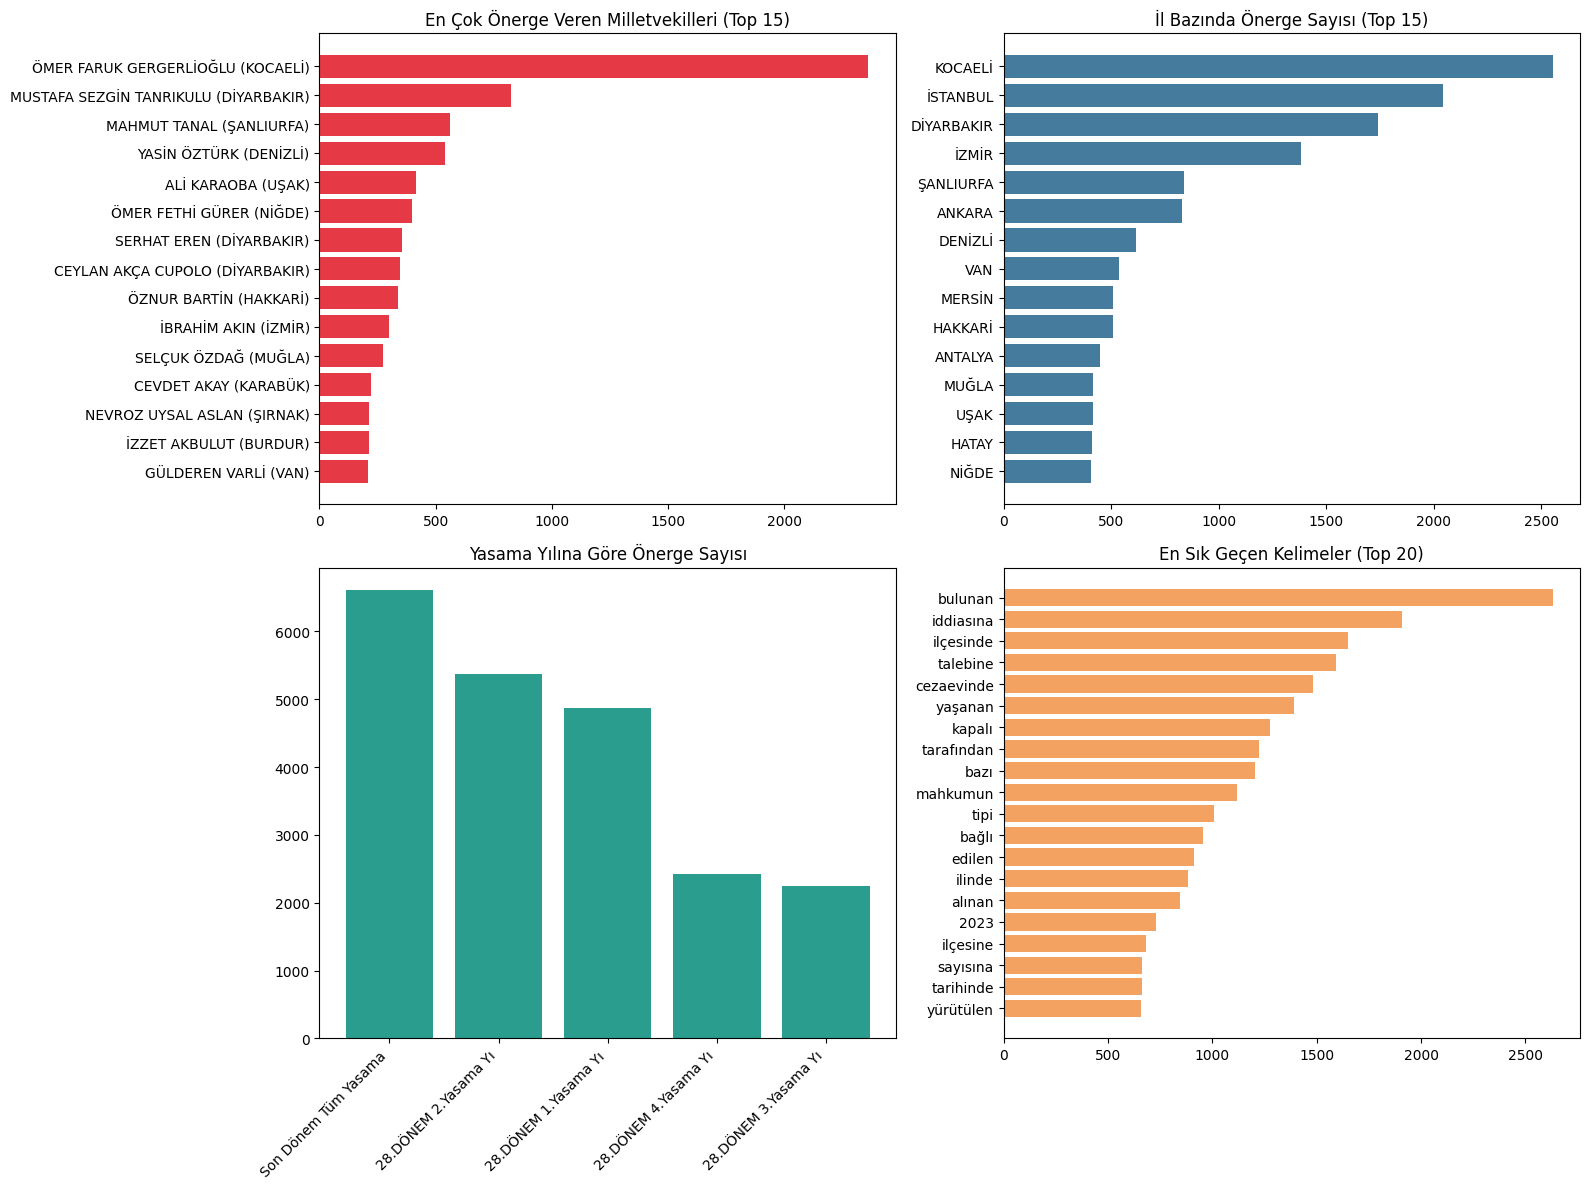

Grafikler oluşturuldu!


In [0]:
#Görselleştirme
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. En aktif 15 milletvekili
ax1 = axes[0, 0]
top15 = mv_pd.head(15)
ax1.barh(top15["onerge_sahibi"] + " (" + top15["il"] + ")", top15["count"], color="#E63946")
ax1.invert_yaxis()
ax1.set_title("En Çok Önerge Veren Milletvekilleri (Top 15)")

# 2. İl dağılımı
ax2 = axes[0, 1]
ax2.barh(il_pd.head(15)["il"], il_pd.head(15)["count"], color="#457B9D")
ax2.invert_yaxis()
ax2.set_title("İl Bazında Önerge Sayısı (Top 15)")

# 3. Yasama yılı trendi
ax3 = axes[1, 0]
ax3.bar(range(len(yil_pd)), yil_pd["count"], color="#2A9D8F")
ax3.set_xticks(range(len(yil_pd)))
ax3.set_xticklabels(yil_pd["yasama_yili_text"].str[:20], rotation=45, ha="right")
ax3.set_title("Yasama Yılına Göre Önerge Sayısı")

# 4. Kelime frekansı
ax4 = axes[1, 1]
ax4.barh(kelime_pd.head(20)["kelime"], kelime_pd.head(20)["count"], color="#F4A261")
ax4.invert_yaxis()
ax4.set_title("En Sık Geçen Kelimeler (Top 20)")

plt.tight_layout()
plt.show()
print("Grafikler oluşturuldu!")